**Step 1: Import all necessary libraries**


In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import timedelta

import warnings
warnings.filterwarnings("ignore")

**Step 2: Load the data**

In [163]:
df = pd.read_csv("data.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [164]:
# Shape of the dataset
rows, columns = df.shape
print(f"Number of Rows: {rows}")
print(f"Number of Columns: {columns}")


Number of Rows: 541909
Number of Columns: 8


In [165]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [166]:
#check the size
df.shape

(541909, 8)

In [167]:
# Missing values per column
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [168]:
#Check the Summary statistics
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [169]:
# List of column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

**Step 3: Data Cleaning**

In [170]:
#droping the rows where the customer id is missing
df.dropna(subset=["CustomerID"], inplace=True)

In [171]:
# removing the cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.contains("C", na=False)]

In [172]:
# removing the rows where quantity and unitprice is negative and zero
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [173]:
# create new column
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [174]:
df.shape

(397884, 9)

In [175]:
# droping the duplicates 
df.drop_duplicates(inplace=True)

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
 8   TotalAmount  392692 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 30.0+ MB


**Step 4: Feature Engineering**

In [177]:
# covverting invoicedate into date format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [178]:
# creating the additional features
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["Weekday"] = df["InvoiceDate"].dt.day_name()

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     392692 non-null  object        
 1   StockCode     392692 non-null  object        
 2   Description   392692 non-null  object        
 3   Quantity      392692 non-null  int64         
 4   InvoiceDate   392692 non-null  datetime64[ns]
 5   UnitPrice     392692 non-null  float64       
 6   CustomerID    392692 non-null  float64       
 7   Country       392692 non-null  object        
 8   TotalAmount   392692 non-null  float64       
 9   InvoiceMonth  392692 non-null  int32         
 10  InvoiceYear   392692 non-null  int32         
 11  InvoiceDay    392692 non-null  int32         
 12  Hour          392692 non-null  int32         
 13  Weekday       392692 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(4), int64(1), object(5)
memory us

**Step 5: Exploratory Data Analysis**

**5.1) Distribution of Quantity purchased**

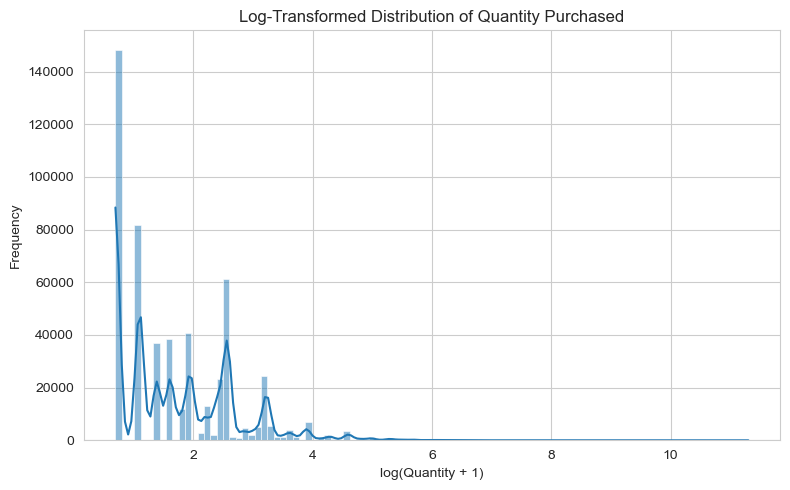

In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data.csv", encoding="latin1")

# Log transform Quantity to reduce skewness
df["Log_Quantity"] = np.log1p(df["Quantity"])

# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Log_Quantity"], bins=100, kde=True)
plt.title("Log-Transformed Distribution of Quantity Purchased")
plt.xlabel("log(Quantity + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("cluster_plots/Distribution of Quantity purchased.png")
plt.show()


**Log Transformation of Quantity**

Purchase quantity shows strong right skewness due to a few high-volume transactions. Applying log1p(Quantity) reduces the impact of outliers and stabilizes the distribution. This transformation improves feature reliability for downstream clustering and customer segmentation.

**5.2) Distribution of Unitprice**

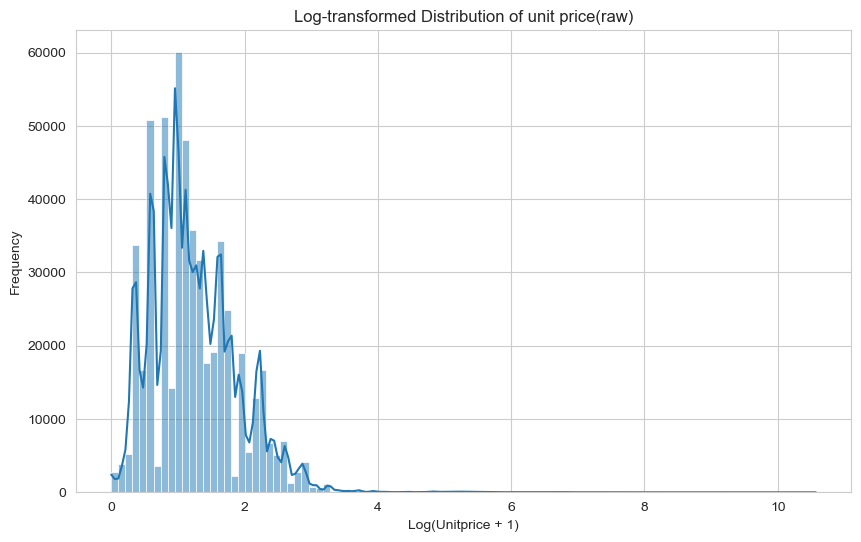

In [221]:

df["Log_UnitPrice"] = np.log1p(df["UnitPrice"])

plt.figure(figsize=(10,6))
sns.histplot(df["Log_UnitPrice"], bins=100, kde= True)
plt.title("Log-transformed Distribution of unit price(raw)")
plt.xlabel("Log(Unitprice + 1)")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("cluster_plots/Distribution of Unitprice.png")
plt.show()

Observation: From the distribution of Unit Price, we observe that:

A large number of products are priced under £10, showing that the platform sells mostly low-cost items.
The distribution is right-skewed, meaning there are a few high-priced outliers, but they are not common.
After applying log transformation, the data becomes more normalized, making patterns and comparisons easier to analyze.
This suggests that pricing strategy and demand are centered around affordable items, which may be important for segmentation or inventory planning.

In [182]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Log_Quantity', 'Log_UnitPrice'],
      dtype='object')

**5.3) Transactions by Hour of Day**

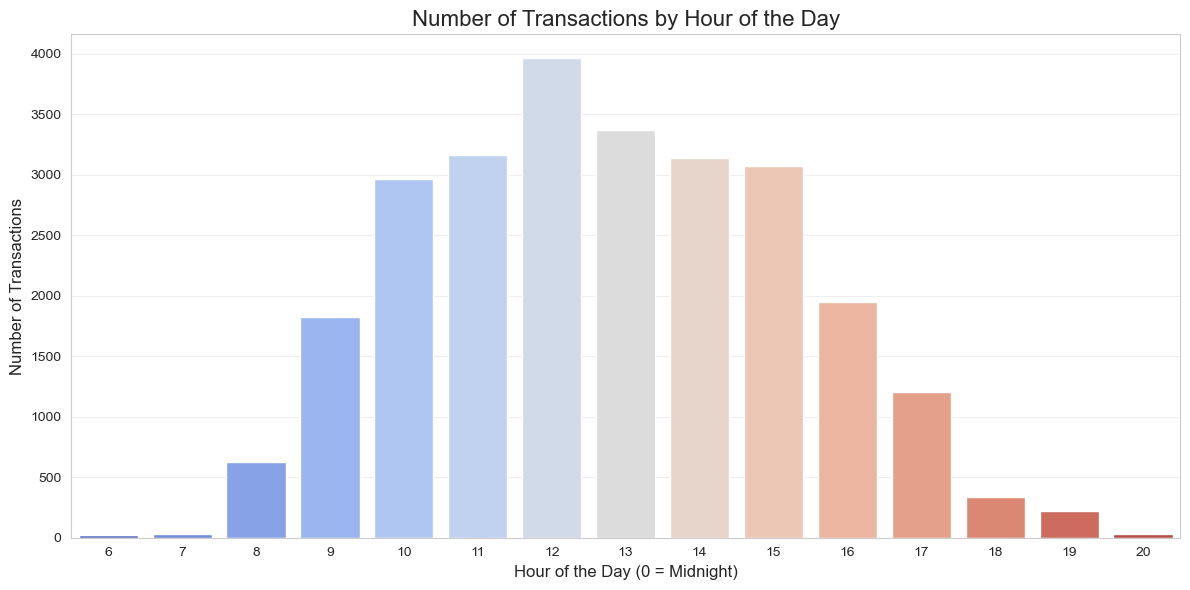

In [232]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Hour"] = df["InvoiceDate"].dt.hour
hourly_transactions = df.groupby("Hour")["InvoiceNo"].nunique()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_transactions.index, y=hourly_transactions.values, palette="coolwarm")
plt.title("Number of Transactions by Hour of the Day", fontsize=16)
plt.xlabel("Hour of the Day (0 = Midnight)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cluster_plots/Transactions by Hour of Day.png")
plt.show()


Observation:

The majority of transactions occur between 9 AM and 5 PM, aligning with typical business hours, which suggests the platform is used mainly during working hours — possibly by businesses or offices.

There is a sharp decline in transactions before 8 AM and after 6 PM, indicating minimal customer activity during early mornings and late evenings.

The peak transaction hours suggest the ideal time to:

Schedule marketing emails or campaigns

Push real-time offers

Ensure system uptime and customer service availability during high-traffic hours.

**5.4) Transactions by Weekday**

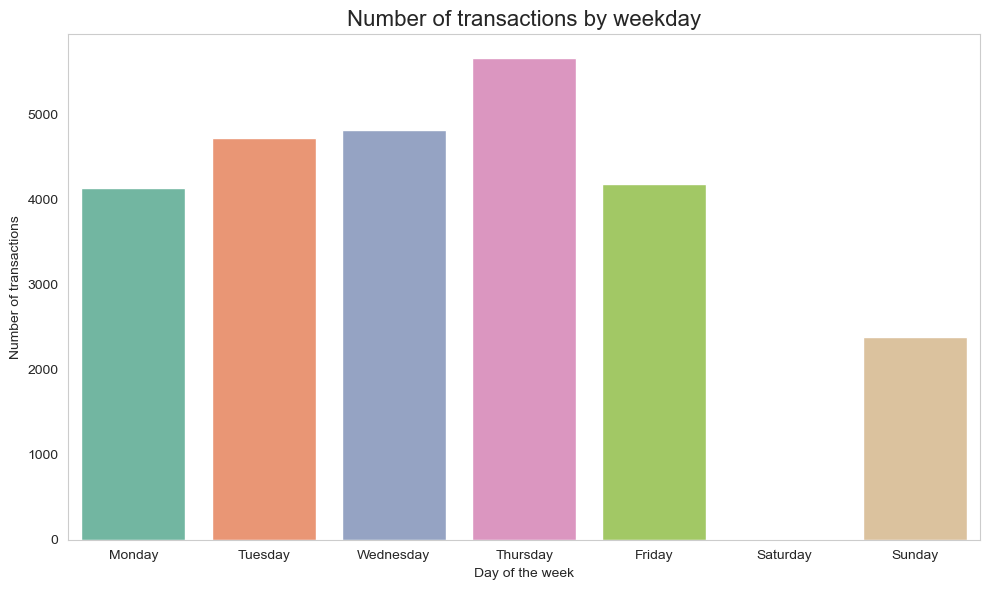

In [234]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Weekday"] = df["InvoiceDate"].dt.weekday

weekday_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday"
}

df["WeekdayName"] = df["Weekday"].map(weekday_map)

# group and plot

weekday_orders = df.groupby("WeekdayName")["InvoiceNo"].nunique().reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

plt.figure(figsize=(10,6))
sns.barplot(x=weekday_orders.index, y=weekday_orders.values, palette="Set2")
plt.title("Number of transactions by weekday", fontsize=16)
plt.xlabel("Day of the week")
plt.ylabel("Number of transactions")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("cluster_plots/Transactions by Weekday.png")
plt.show()
        

 Observation:

Most transactions occur on weekdays, with Thursday and Wednesday typically being the busiest days.
Weekends (especially Sunday) show a significant drop in activity, indicating that either:
The business doesn’t operate or ship on weekends, or
Customers prefer making purchases during workdays, possibly suggesting B2B (business-to-business) behavior.
This pattern is valuable for:
Planning inventory restocking and logistics around peak days.
Scheduling marketing campaigns earlier in the week for maximum visibility.
Avoiding major launches on weekends, as engagement is likely lower.

**5.5) Top 10 Countries by Transaction Volume**

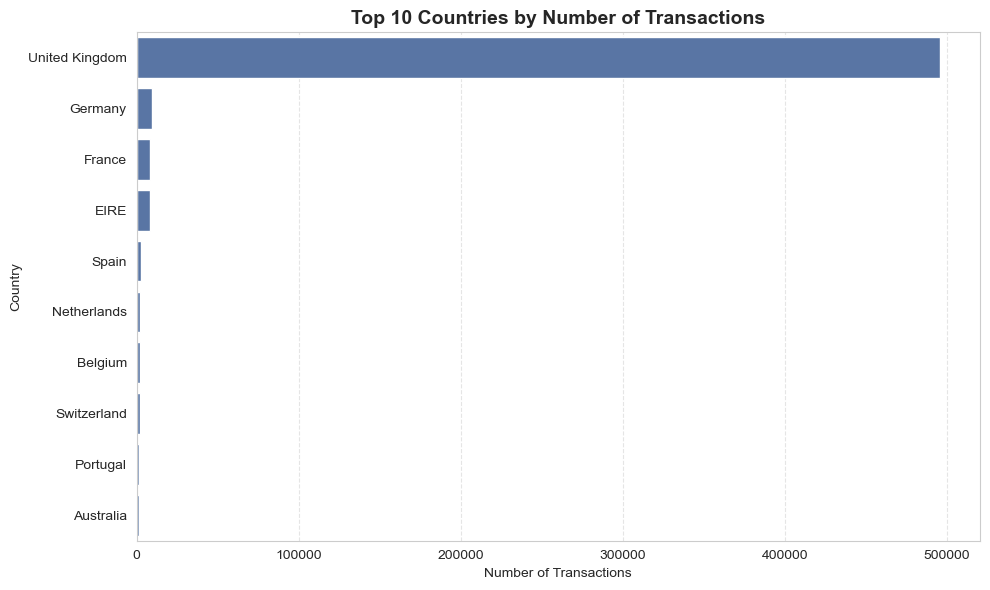

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count transactions per country
country_counts = df["Country"].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    color="#4c72b0"   # clean professional color
)

plt.title("Top 10 Countries by Number of Transactions", fontsize=14, fontweight="bold")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("cluster_plots/top 10 country.png")
plt.show()


**5.6) Top 10 customers by Total Spend**

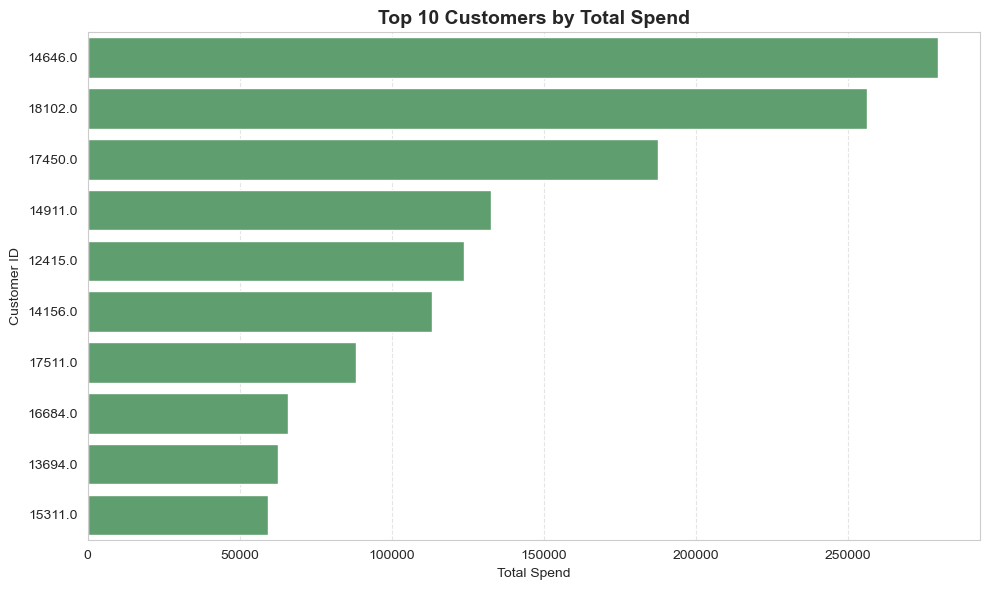

In [236]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Calculate total spend per customer
top_customers = ( df.groupby("CustomerID")["TotalAmount"].sum().sort_values(ascending=False).head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str),
    color="#55a868"
)

plt.title("Top 10 Customers by Total Spend", fontsize=14, fontweight="bold")
plt.xlabel("Total Spend")
plt.ylabel("Customer ID")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("cluster_plots/total spend.png")
plt.show()


**5.7) Top 10 Most sold products**

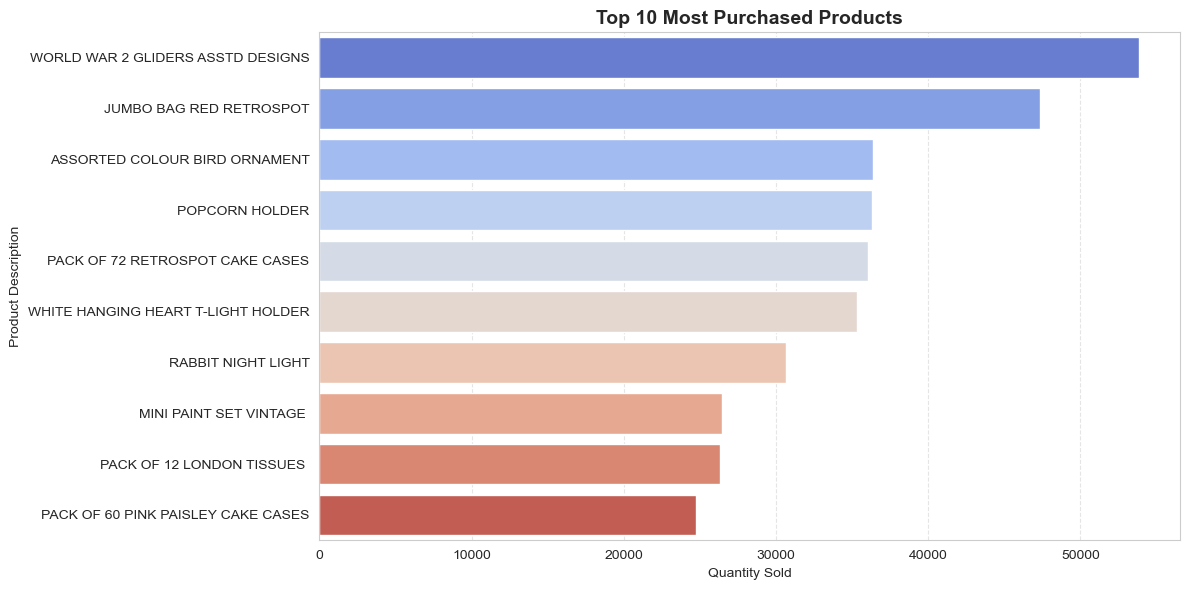

In [237]:


# Calculate top 10 products by total quantity sold
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="coolwarm"
)

plt.title("Top 10 Most Purchased Products", fontsize=14, fontweight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Description")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("cluster_plots/most purchased.png")
plt.show()


**5.8) RFM Distribution (Recency, Frequency, Monetary)**

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          2      0.00
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


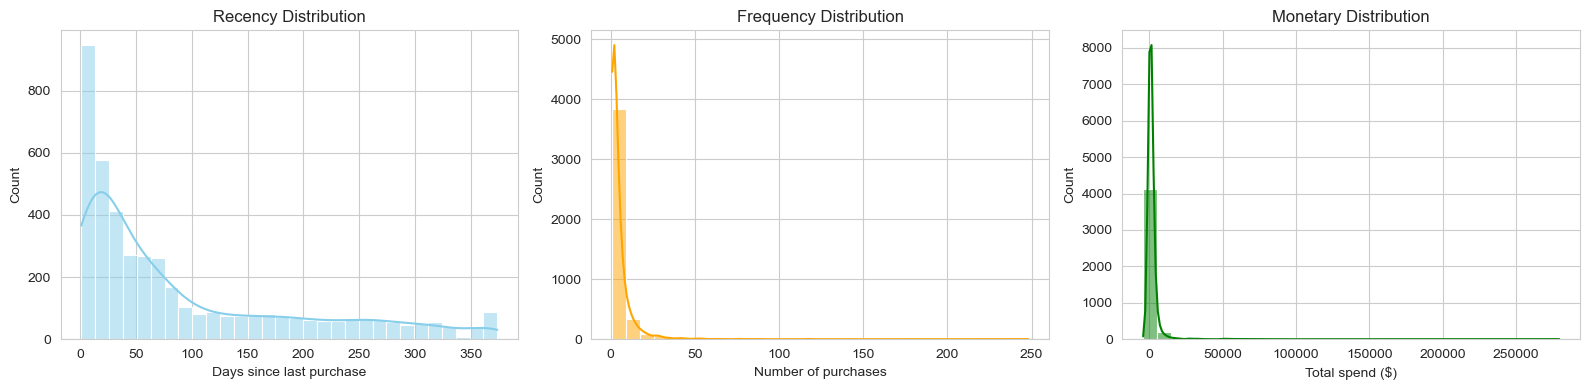

In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure TotalAmount exists
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Reference date for Recency calculation
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Group by CustomerID to calculate RFM
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                   # Frequency
    "TotalAmount": "sum"                                      # Monetary
}).rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
})

# Display RFM table
print(rfm.head())

# Plot histograms for each RFM component
plt.figure(figsize=(16, 4))

# Recency
plt.subplot(1, 3, 1)
sns.histplot(rfm["Recency"], bins=30, color="skyblue", kde=True)
plt.title("Recency Distribution")
plt.xlabel("Days since last purchase")

# Frequency
plt.subplot(1, 3, 2)
sns.histplot(rfm["Frequency"], bins=30, color="orange", kde=True)
plt.title("Frequency Distribution")
plt.xlabel("Number of purchases")

# Monetary
plt.subplot(1, 3, 3)
sns.histplot(rfm["Monetary"], bins=30, color="green", kde=True)
plt.title("Monetary Distribution")
plt.xlabel("Total spend ($)")

plt.tight_layout()
plt.savefig("cluster_plots/RFM.png")
plt.show()


Observation: RFM Distribution

**Recency:** Most customers made their last purchase within the last 100 days, showing active recent engagement. A few have not returned in a long time.

**Frequency:** The majority of customers have a low purchase count, reinforcing earlier findings that most are infrequent buyers.

**Monetary:** Spending is highly skewed, with a small group of customers contributing a large portion of total revenue.
These patterns highlight the importance of segmenting customers: some need reactivation (high recency), others are loyal high spenders (high frequency and monetary).
Businesses can use this segmentation to target campaigns more effectively and improve Customer Lifetime Value (CLV).

            Recency  Frequency  Monetary
Recency    1.000000  -0.259342 -0.132001
Frequency -0.259342   1.000000  0.566122
Monetary  -0.132001   0.566122  1.000000


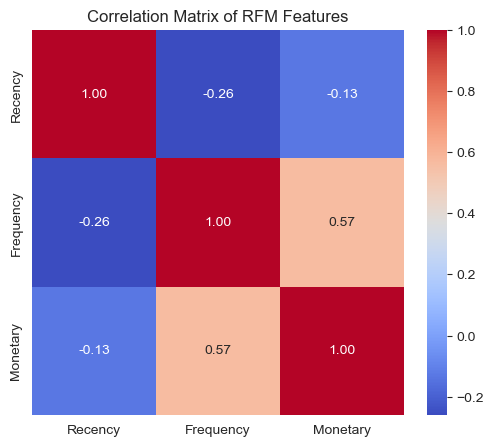

In [229]:
# Compute correlation matrix
corr_matrix = rfm[['Recency', 'Frequency', 'Monetary']].corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of RFM Features")
plt.savefig("cluster_plots/Correlation Matrix of RFM Features.png")
plt.show()


In [190]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,293.362500
50%,50.000000,3.000000,648.075000
75%,143.000000,5.000000,1611.725000
max,374.000000,248.000000,279489.020000



**5.9) Sales trends by Country over time**

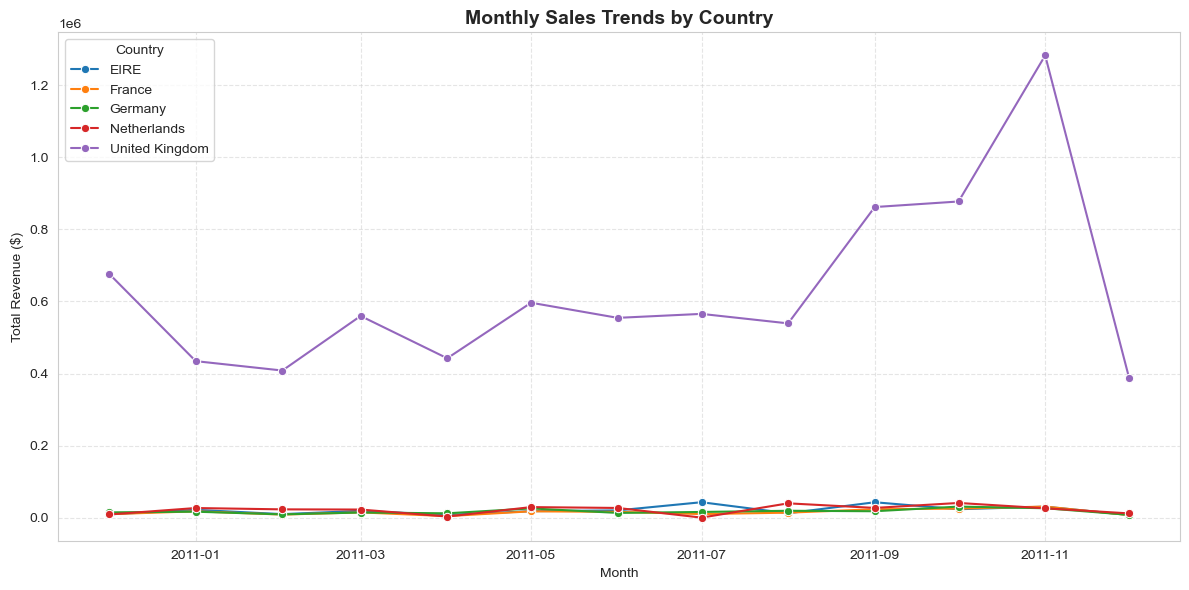

In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Ensure TotalAmount exists
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Extract Year and Month from InvoiceDate (if not already present)
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

# Get top 5 countries by total revenue
top_countries = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(5).index

# Filter data for those countries
filtered_data = df[df["Country"].isin(top_countries)]

# Group by month and country
monthly_sales = (filtered_data.groupby(["InvoiceYear", "InvoiceMonth", "Country"])["TotalAmount"].sum().reset_index())

# Create MonthYear column for proper sorting on x-axis
monthly_sales["MonthYear"] = pd.to_datetime(dict(year=monthly_sales.InvoiceYear, month=monthly_sales.InvoiceMonth, day=1))

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales,x="MonthYear",y="TotalAmount",hue="Country",marker="o",palette="tab10")

plt.title("Monthly Sales Trends by Country", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("cluster_plots/Monthly Sales Trends by Country.png")
plt.show()


**5.10)Boxplot of total spend per country**

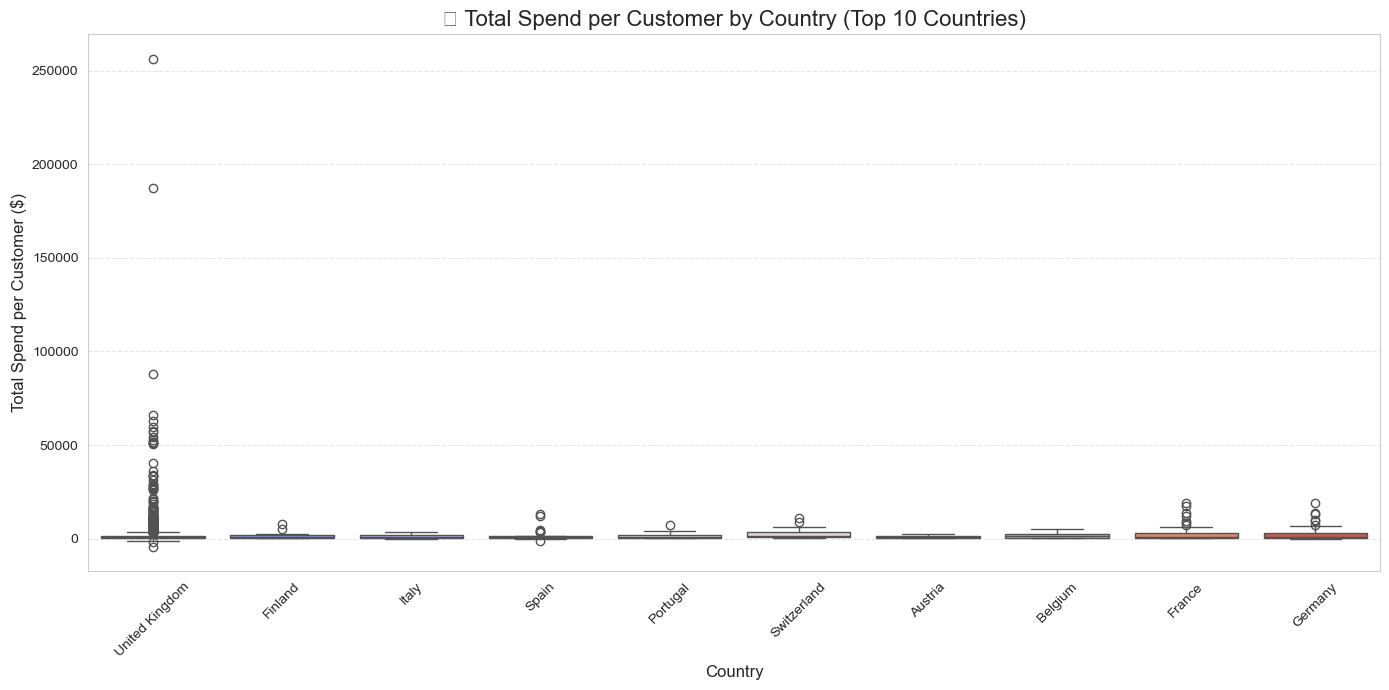

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure we use the correct DataFrame
df["TotalAmount"] = df["UnitPrice"] * df["Quantity"]  # create TotalAmount if not already

# Calculate total spend per customer
customer_spend = df.groupby(["CustomerID", "Country"])["TotalAmount"].sum().reset_index()

# Get top 10 countries by number of unique customers
top_countries = customer_spend["Country"].value_counts().head(10).index

# Filter data
filtered_spend = customer_spend[customer_spend["Country"].isin(top_countries)]

# Set Seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(14,7))
sns.boxplot(
    data=filtered_spend, 
    x="Country", 
    y="TotalAmount", 
    palette="coolwarm"
)
plt.title("💰 Total Spend per Customer by Country (Top 10 Countries)", fontsize=16)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Spend per Customer ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("cluster_plots/Total Spend per Customer.png")
plt.show()


**5.11) Average order value by country**

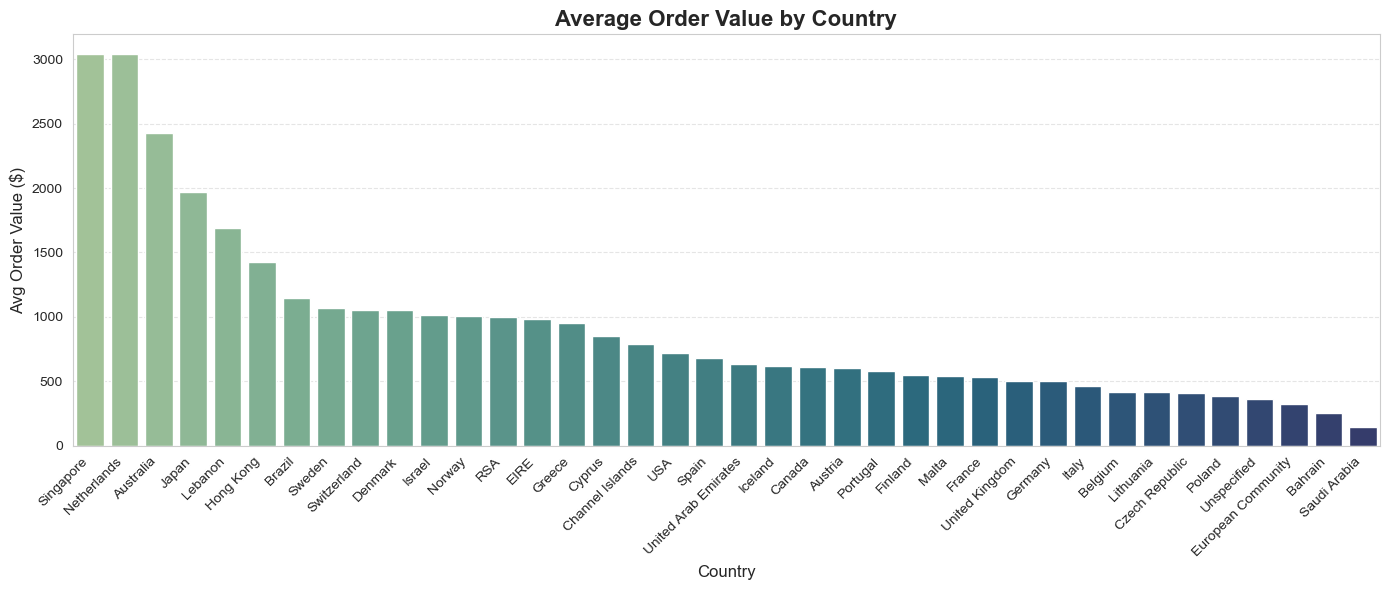

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure TotalAmount exists
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Remove negative or zero quantities and prices
clean_data = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Calculate average order value per country
country_order_value = (
    clean_data.groupby("Country")["TotalAmount"].sum() /
    clean_data.groupby("Country")["InvoiceNo"].nunique()
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(14,6))
sns.barplot(
    x=country_order_value.index,
    y=country_order_value.values,
    palette="crest"
)

plt.title("Average Order Value by Country", fontsize=16, fontweight="bold")
plt.ylabel("Avg Order Value ($)", fontsize=12)
plt.xlabel("Country", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("cluster_plots/Average Order Value by Country.png")
plt.show()


In [194]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Log_Quantity', 'Log_UnitPrice',
       'Hour', 'Weekday', 'WeekdayName', 'TotalAmount', 'InvoiceYear',
       'InvoiceMonth'],
      dtype='object')

**Step 6: Feature engineering**

In [195]:
import pandas as pd
from datetime import timedelta

# Ensure TotalAmount exists
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Ensure InvoiceDate is datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Set the reference date (one day after last invoice)
reference_date = df["InvoiceDate"].max() + timedelta(days=1)

# Group by CustomerID to calculate RFM
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                   # Frequency
    "TotalAmount": "sum"                                      # Monetary
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Display top 5 customers
print(rfm.head(5))

# Check for missing values
print(rfm.isnull().sum())


   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          2      0.00
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


In [196]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Log_Quantity', 'Log_UnitPrice',
       'Hour', 'Weekday', 'WeekdayName', 'TotalAmount', 'InvoiceYear',
       'InvoiceMonth'],
      dtype='object')

**Step 7: Data Standardization**

In [197]:
from sklearn.preprocessing import StandardScaler

# Select only the RFM features for clustering
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
rfm_scaled = scaler.fit_transform(rfm_features)

# Optional: convert scaled data back into a DataFrame for readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,2.322023,-0.329362,-0.231001
1,-0.893733,0.206102,0.293432
2,-0.169196,-0.115176,-0.012316
3,-0.725005,-0.436455,-0.017146
4,2.163220,-0.436455,-0.190312


**Step 8: Determine Optimal number of Clusters (Elbow & Silhouette Method)**

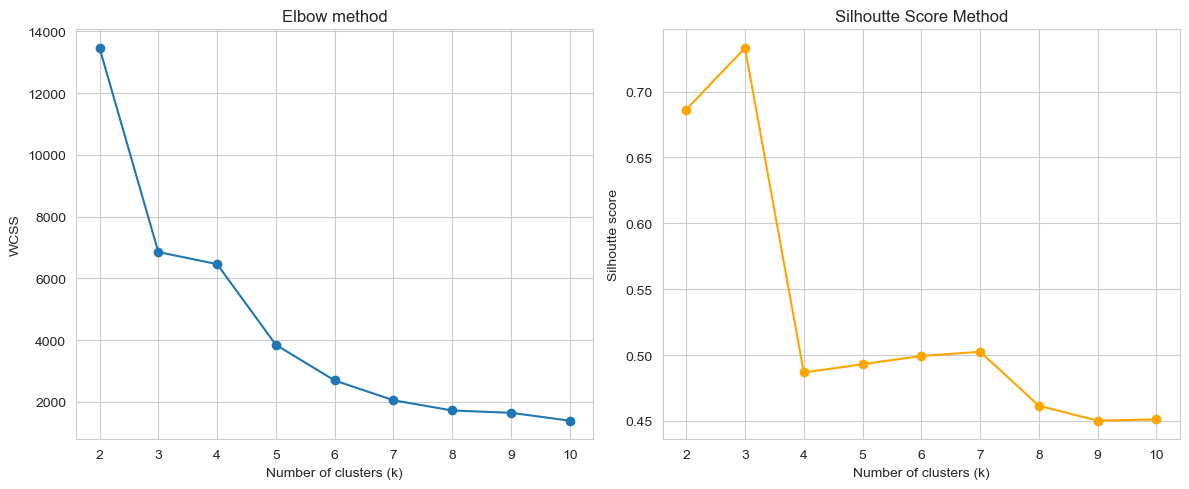

In [225]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
K = range(2,11)  # try cluster sizes from 2 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_) # WCSS for elbow method
    score = silhouette_score(rfm_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

#plot elbow method

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K, wcss, marker="o")
plt.title("Elbow method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker="o", color="orange")
plt.title("Silhoutte Score Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhoutte score")

plt.tight_layout()
plt.savefig("cluster_plots/Elbow method Silhoutte Score Method.png")
plt.show()

**Step 9: Applying final Clustering Model (KMeans)**

In [199]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Assume rfm DataFrame exists with columns: Recency, Frequency, Monetary
# Optional: remove CustomerID for scaling
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# K-Means clustering
kmeans_final = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

# View distribution of clusters
print(rfm["Cluster"].value_counts())

# Preview top 5 rows
rfm.head()


Cluster
3    3090
1    1077
0     194
2      11
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,2,0.00,1
1,12347.0,2,7,4310.00,3
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,3
4,12350.0,310,1,334.40,1


**step 10: Visualize the clusters and profile the segments**


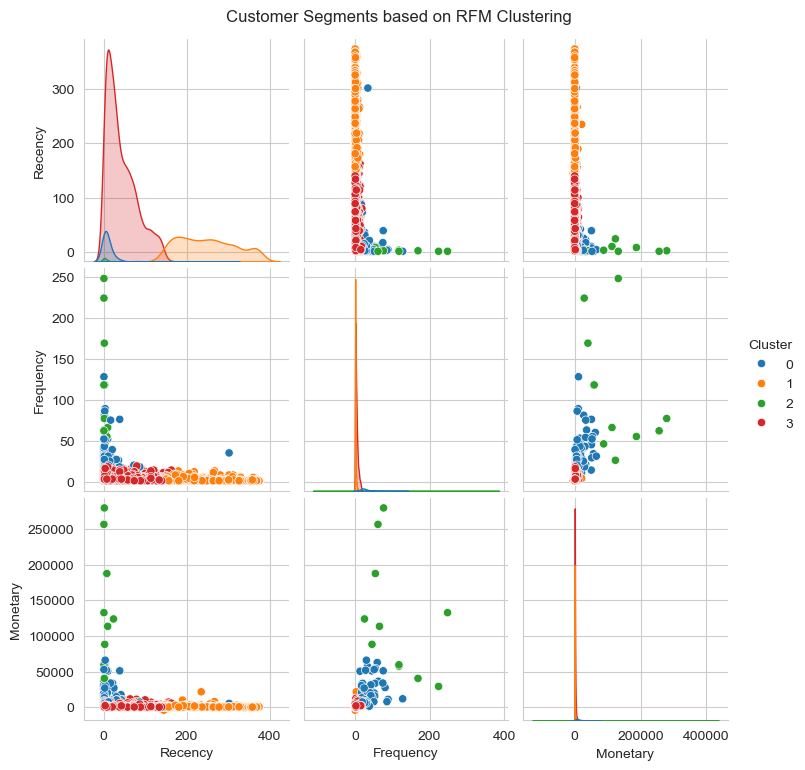

In [224]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])
rfm_scaled_df["Cluster"] = rfm["Cluster"]

# Visualize clusters
sns.pairplot(rfm, vars=["Recency", "Frequency", "Monetary"], hue="Cluster", palette="tab10")
plt.suptitle("Customer Segments based on RFM Clustering", y=1.02)
plt.savefig("cluster_plots/Customer Segments based on RFM Clustering.png")
plt.show()

In [201]:
# Profile segments
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Num_Customers"}).reset_index()

# Round values for better readability
cluster_profile = cluster_profile.round(2)
cluster_profile

,Cluster,Recency,Frequency,Monetary,Num_Customers
0,0,10.75,28.51,12168.26,194
1,1,248.93,1.81,455.11,1077
2,2,5.09,109.91,124312.31,11
3,3,42.78,4.37,1320.98,3090


Customer Segmentation Results

We successfully clustered customers into 4 distinct segments based on their RFM values.
The segments show clear differences in purchasing behavior:
Some clusters have low recency (recent buyers), high frequency, and high monetary value – indicating loyal and valuable customers.
Others have high recency, low frequency, and low monetary – likely at-risk or churned customers.
This segmentation can be used to target marketing, design loyalty programs, and reactivate inactive customers.

**Step 11: Apply Hierarchical Clustering**

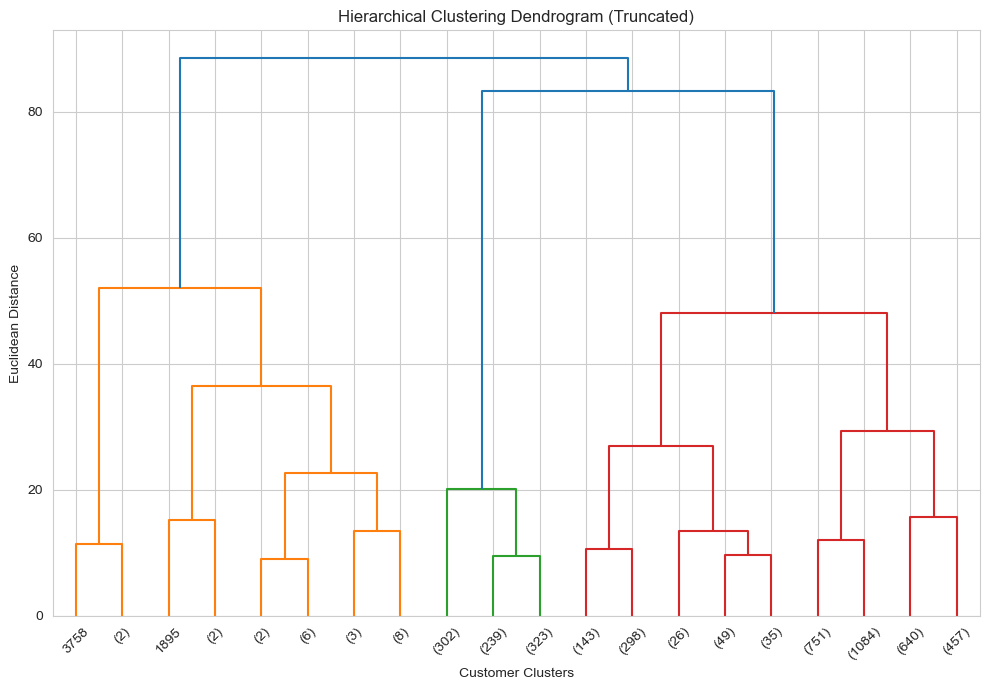

In [202]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Customer Clusters")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.savefig("cluster_plots/hierarchical_dendrogram.png")
plt.show()


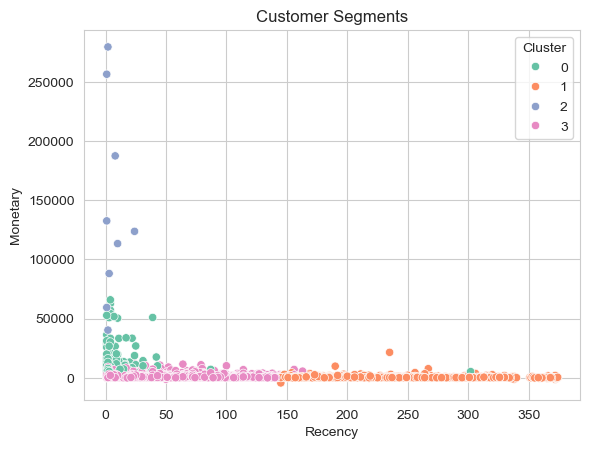

In [223]:
# Visualize the Hierarchical Clusters
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='Set2')
plt.title('Customer Segments')
plt.savefig("cluster_plots/Customer Segments.png")
plt.show()

Customer Segmentation using Hierarchical Clustering
We applied Agglomerative Clustering using Ward’s method based on scaled RFM features. The resulting segments reveal distinguishable patterns across recency and monetary value.

Cluster 0: High-value, frequent customers
Cluster 1: Recently inactive, moderate spenders
Cluster 2: Low-frequency and low-monetary customers
Cluster 3: Irregular high-spenders or new users
These clusters offer marketing teams distinct groups to target with personalized strategies.

**Step 12: Apply DBSCAN:**

In [204]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5, metric="euclidean")
rfm["DBSCAN_Cluster"] = db.fit_predict(rfm_scaled)

# Convert cluster labels to string (useful for plotting)
rfm["DBSCAN_Cluster"] = rfm["DBSCAN_Cluster"].astype(str)

# Print cluster counts
print("DBSCAN Cluster Counts:\n", rfm["DBSCAN_Cluster"].value_counts())


DBSCAN Cluster Counts:
 DBSCAN_Cluster
0     4313
-1      48
1        6
2        5
Name: count, dtype: int64


**Step 13: visualize DBSCAN Clusters and profile the cluster(DBSCAN)**

DBSCAN Cluster Counts:
 DBSCAN_Cluster
0     4313
-1      48
1        6
2        5
Name: count, dtype: int64


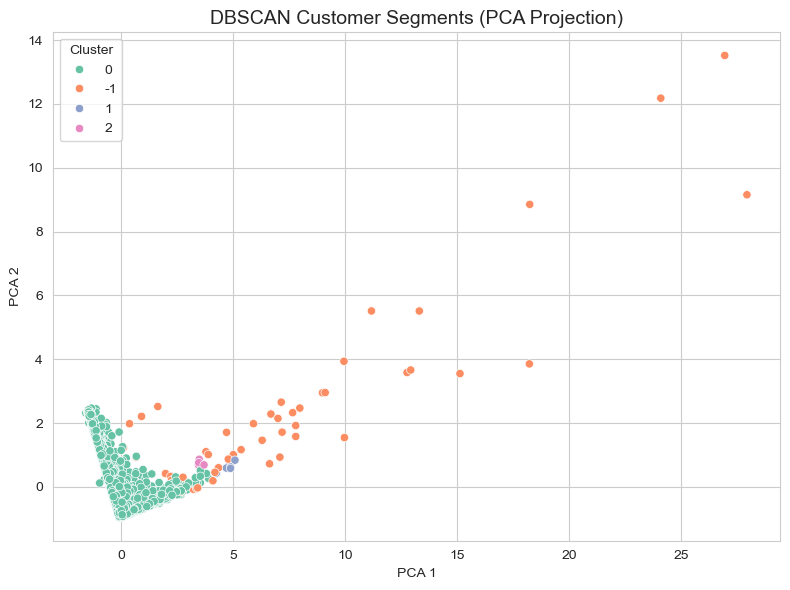

In [222]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Scale RFM features
# -----------------------------
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

# -----------------------------
# Apply DBSCAN
# -----------------------------
db = DBSCAN(eps=0.5, min_samples=5, metric="euclidean")
rfm["DBSCAN_Cluster"] = db.fit_predict(rfm_scaled)

# Convert cluster labels to string for plotting
rfm["DBSCAN_Cluster"] = rfm["DBSCAN_Cluster"].astype(str)

# Print cluster distribution
print("DBSCAN Cluster Counts:\n", rfm["DBSCAN_Cluster"].value_counts())

# -----------------------------
# PCA for Visualization
# -----------------------------
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

# -----------------------------
# Plot DBSCAN Clusters
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm,
    x="PCA1",
    y="PCA2",
    hue="DBSCAN_Cluster",
    palette="Set2"
)
plt.title("DBSCAN Customer Segments (PCA Projection)", fontsize=14)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("cluster_plots/DBSCAN Customer Segments.png")
plt.show()


In [206]:

rfm["DBSCAN_Cluster"] = rfm["DBSCAN_Cluster"].astype(int)
valid_clusters = rfm[rfm["DBSCAN_Cluster"] != -1]

#Group by DBSCAN cluster

dbscan_profile = valid_clusters.groupby("DBSCAN_Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "count"}).reset_index()

dbscan_profile

,DBSCAN_Cluster,Recency,Frequency,Monetary,count
0,0,92.954092,4.407141,1318.958452,4313
1,1,3.833333,50.333333,16995.101667,6
2,2,8.200000,21.800000,27717.556000,5


**Step 14: Compare Clustering Models**

**14.1. Silhoutte Score Comparison (KMeans & Hierarchical)**


In [207]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# -----------------------------
# KMeans Silhouette Score
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

kmeans_score = silhouette_score(rfm_scaled, rfm["KMeans_Cluster"])
print(f"KMeans Silhouette Score: {kmeans_score:.3f}")

# -----------------------------
# Hierarchical Clustering
# -----------------------------
hc = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm["HC_Cluster"] = hc.fit_predict(rfm_scaled)

hc_score = silhouette_score(rfm_scaled, rfm["HC_Cluster"])
print(f"Hierarchical Clustering Silhouette Score: {hc_score:.3f}")


KMeans Silhouette Score: 0.614
Hierarchical Clustering Silhouette Score: 0.589


**14.2. DBSCAN Noise ratio and cluster Stats**

In [208]:
noise_count = ( rfm["DBSCAN_Cluster"] == -1).sum()
total_points = rfm.shape[0]
noise_ratio = noise_count / total_points


print(f"DBSCAN Noise Ratio: {noise_ratio:.2%}")
print(f"DBSCAN CLusters (excluding noice): {rfm["DBSCAN_Cluster"].nunique() - (1 if -1 in rfm["DBSCAN_Cluster"].unique() else 0)}")

DBSCAN Noise Ratio: 1.10%
DBSCAN CLusters (excluding noice): 3


**Step 15: Customer Prediction modeling**

**15.1: define a target variable for prediction**

In [209]:
# Find high-value cluster automatically
cluster_means = rfm.groupby('KMeans_Cluster')['Monetary'].mean()
high_value_cluster = cluster_means.idxmax()

rfm['Customer_Label'] = rfm['KMeans_Cluster'].apply(
    lambda x: 1 if x == high_value_cluster else 0
)

rfm['Customer_Label'].value_counts()


Customer_Label
0    4361
1      11
Name: count, dtype: int64

In [210]:
# Calculate mean RFM values per cluster
rfm_kmeans_profile = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

# Add count of customers in each cluster
rfm_kmeans_profile['CustomerCount'] = rfm['KMeans_Cluster'].value_counts()

# Display the profile
rfm_kmeans_profile.sort_values(by='Monetary', ascending=False)

,Recency,Frequency,Monetary,CustomerCount
KMeans_Cluster,,,,
2,5.1,109.9,124312.3,11
0,10.8,28.5,12168.3,194
3,42.8,4.4,1321.0,3090
1,248.9,1.8,455.1,1077


In [211]:
cluster_profile = rfm.groupby('KMeans_Cluster').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Customer_Count=('CustomerID', 'count')
).reset_index()


In [212]:
def label_segment(row):
    if row['Recency_Mean'] <= 30 and row['Frequency_Mean'] >= 5 and row['Monetary_Mean'] >= 500:
        return 'High-Value Customers'
    elif row['Recency_Mean'] <= 60 and row['Frequency_Mean'] >= 3:
        return 'Loyal Customers'
    elif row['Recency_Mean'] >= 90:
        return 'Churned Customers'
    else:
        return 'Low-Value Customers'

cluster_profile['Segment_Label'] = cluster_profile.apply(label_segment, axis=1)


In [213]:
rfm = rfm.merge(
    cluster_profile[['KMeans_Cluster', 'Segment_Label']],
    on='KMeans_Cluster',
    how='left'
)

rfm.rename(columns={'Segment_Label': 'Segment'}, inplace=True)


In [214]:
rfm[['CustomerID', 'KMeans_Cluster', 'Segment']].head()


,CustomerID,KMeans_Cluster,Segment
0,12346.0,1,Churned Customers
1,12347.0,3,Loyal Customers
2,12348.0,3,Loyal Customers
3,12349.0,3,Loyal Customers
4,12350.0,1,Churned Customers


In [215]:
rfm.head()



,CustomerID,Recency,Frequency,Monetary,Cluster,DBSCAN_Cluster,PCA1,PCA2,KMeans_Cluster,HC_Cluster,Customer_Label,Segment
0,12346.0,326,2,0.00,1,0,-1.250581,1.972492,1,2,0,Churned Customers
1,12347.0,2,7,4310.00,3,0,0.664489,-0.667714,3,0,0,Loyal Customers
2,12348.0,75,4,1797.24,3,0,-0.021059,-0.175201,3,0,0,Loyal Customers
3,12349.0,19,1,1757.55,3,0,-0.029213,-0.728563,3,0,0,Loyal Customers
4,12350.0,310,1,334.40,1,0,-1.236523,1.828648,1,2,0,Churned Customers


In [216]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Segment']


**15.2. split data for training and testing**

In [217]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

**step 16: Training Models (Logistic regression, RandomForest)**

In [218]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Ensure y_train is 1D
y_train = y_train.squeeze()

# Initialize models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rfc = RandomForestClassifier(random_state=42)

# Train models
log_reg.fit(X_train, y_train)
rfc.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

**16.1 Evaluation of models**

In [219]:
from sklearn.metrics import classification_report, confusion_matrix

#evaluation function

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 50)

evaluate_model(log_reg, "Logistic Regression")
evaluate_model(rfc, "Random Forest")

Model: Logistic Regression
[[322   0   1]
 [  1  60   1]
 [  0   0 927]]
                      precision    recall  f1-score   support

   Churned Customers       1.00      1.00      1.00       323
High-Value Customers       1.00      0.97      0.98        62
     Loyal Customers       1.00      1.00      1.00       927

            accuracy                           1.00      1312
           macro avg       1.00      0.99      0.99      1312
        weighted avg       1.00      1.00      1.00      1312

--------------------------------------------------
Model: Random Forest
[[323   0   0]
 [  0  60   2]
 [  2   0 925]]
                      precision    recall  f1-score   support

   Churned Customers       0.99      1.00      1.00       323
High-Value Customers       1.00      0.97      0.98        62
     Loyal Customers       1.00      1.00      1.00       927

            accuracy                           1.00      1312
           macro avg       1.00      0.99      0.99      131

**16.2. Interpret Results & Feature Importance**

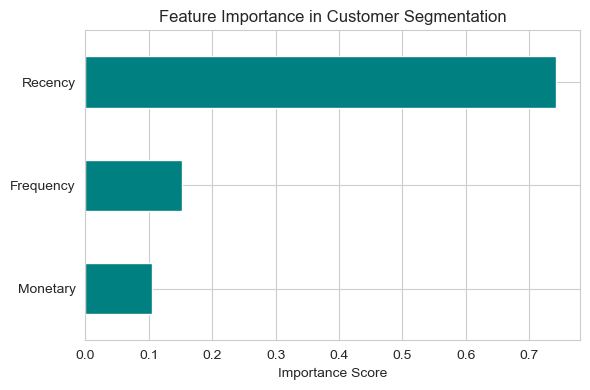

In [220]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# Extract feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

# Plot feature importance
feature_importance.plot(kind='barh', figsize=(6,4), color='teal')
plt.title('Feature Importance in Customer Segmentation')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("cluster_plots/feature_importance.png")
plt.show()